# Task 2: Unemployment Analysis with Python

**Track:** Data Science
**Objective:** Perform exploratory data analysis on unemployment data to uncover regional and temporal trends, with a focus on the impact of the COVID-19 pandemic on unemployment rates in India.

**Tech Stack:** Python, pandas, matplotlib, seaborn, Jupyter Notebook

## 1. Load Dataset & Initial Inspection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

# Load dataset
df = pd.read_csv('unemployment_india.csv')
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

print(f'Dataset Shape: {df.shape}')
print(f'\nFirst 5 rows:')
display(df.head())
print(f'\nColumn Names: {list(df.columns)}')
print(f'\nData Types:')
print(df.dtypes)
print(f'\nDate Range: {df["Date"].min()} to {df["Date"].max()}')
print(f'States: {df["State"].nunique()}')

Dataset Shape: (720, 7)

First 5 rows:


,Date,State,Unemployment_Rate,Employment_Rate,Labour_Participation_Rate,Year,Month
0,2019-01-31,Maharashtra,5.26,93.96,41.16,2019,1
1,2019-02-28,Maharashtra,6.69,88.98,52.02,2019,2
2,2019-03-31,Maharashtra,5.79,93.29,46.08,2019,3
3,2019-04-30,Maharashtra,5.85,91.53,48.64,2019,4
4,2019-05-31,Maharashtra,7.19,92.12,45.84,2019,5



Column Names: ['Date', 'State', 'Unemployment_Rate', 'Employment_Rate', 'Labour_Participation_Rate', 'Year', 'Month']

Data Types:
Date                         datetime64[us]
State                                   str
Unemployment_Rate                   float64
Employment_Rate                     float64
Labour_Participation_Rate           float64
Year                                  int32
Month                                 int32
dtype: object

Date Range: 2019-01-31 00:00:00 to 2022-12-31 00:00:00
States: 15


## 2. Data Quality Check

In [2]:
# Null value check
print('=== NULL VALUES ===')
print(df.isnull().sum())

# Duplicate check
print(f'\nDuplicate rows: {df.duplicated().sum()}')

# Descriptive statistics
print('\n=== DESCRIPTIVE STATISTICS ===')
display(df.describe())

=== NULL VALUES ===
Date                         0
State                        0
Unemployment_Rate            0
Employment_Rate              0
Labour_Participation_Rate    0
Year                         0
Month                        0
dtype: int64

Duplicate rows: 0

=== DESCRIPTIVE STATISTICS ===


,Date,Unemployment_Rate,Employment_Rate,Labour_Participation_Rate,Year,Month
count,720,720.000000,720.000000,720.000000,720.000000,720.000000
mean,2021-01-14 03:30:00,8.465194,89.040347,49.630153,2020.500000,6.500000
min,2019-01-31 00:00:00,1.190000,70.130000,40.060000,2019.000000,1.000000
25%,2020-01-23 06:00:00,5.540000,86.547500,44.632500,2019.750000,3.750000
50%,2021-01-15 12:00:00,7.635000,89.770000,49.225000,2020.500000,6.500000
75%,2022-01-07 18:00:00,10.600000,92.200000,54.637500,2021.250000,9.250000
max,2022-12-31 00:00:00,25.930000,97.790000,59.990000,2022.000000,12.000000
std,NaN,4.156254,4.435646,5.863835,1.118811,3.454452


## 3. Region-wise Average Unemployment Rates

=== STATE-WISE AVERAGE UNEMPLOYMENT ===


,State,Avg_Unemployment_Rate
0,Odisha,12.254375
1,West Bengal,12.214792
2,Bihar,11.970625
3,Telangana,11.418542
4,Karnataka,9.397083
5,Rajasthan,9.031875
6,Tamil Nadu,8.759167
7,Uttar Pradesh,7.731458
8,Andhra Pradesh,7.715417
9,Maharashtra,7.591042


C:\Users\ASUS\AppData\Local\Temp\ipykernel_12728\1026280056.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=state_avg, x='Avg_Unemployment_Rate', y='State', palette='viridis')


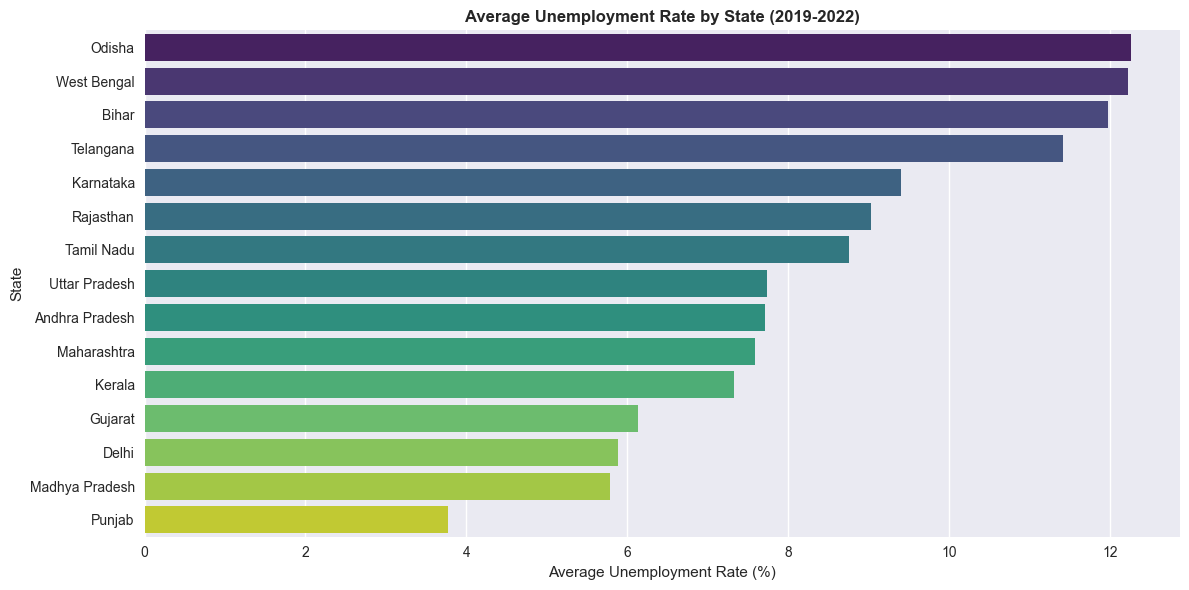

C:\Users\ASUS\AppData\Local\Temp\ipykernel_12728\1026280056.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10, x='Avg_Unemployment_Rate', y='State', palette='Reds_r')


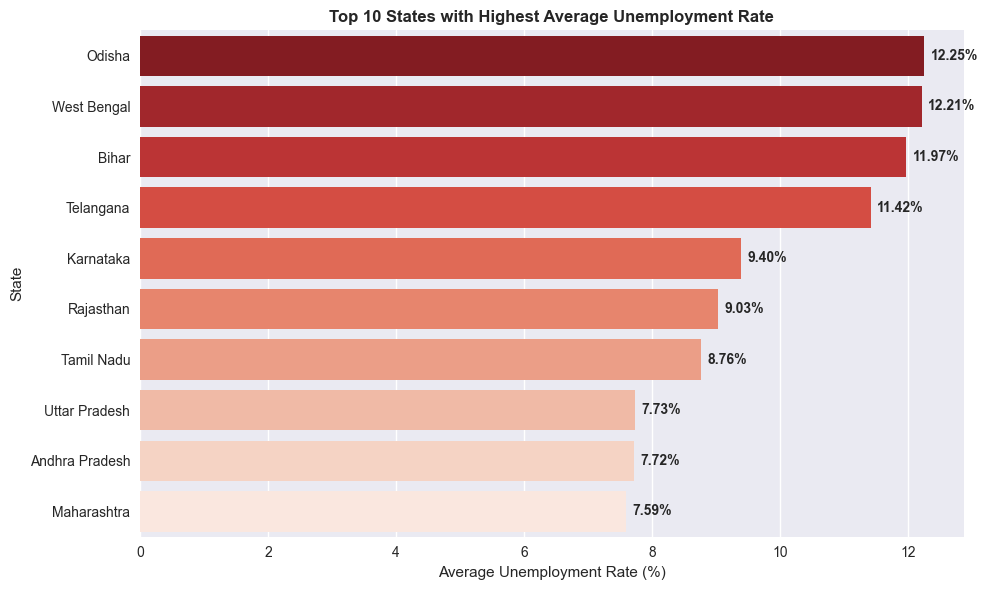

In [3]:
# State-wise average unemployment
state_avg = df.groupby('State')['Unemployment_Rate'].mean().sort_values(ascending=False).reset_index()
state_avg.columns = ['State', 'Avg_Unemployment_Rate']

print('=== STATE-WISE AVERAGE UNEMPLOYMENT ===')
display(state_avg)

# Bar chart: All states
plt.figure(figsize=(12, 6))
sns.barplot(data=state_avg, x='Avg_Unemployment_Rate', y='State', palette='viridis')
plt.title('Average Unemployment Rate by State (2019-2022)', fontweight='bold')
plt.xlabel('Average Unemployment Rate (%)')
plt.tight_layout()
plt.show()

# Top 10 states with highest unemployment
top10 = state_avg.head(10)
plt.figure(figsize=(10, 6))
sns.barplot(data=top10, x='Avg_Unemployment_Rate', y='State', palette='Reds_r')
plt.title('Top 10 States with Highest Average Unemployment Rate', fontweight='bold')
plt.xlabel('Average Unemployment Rate (%)')
for i, v in enumerate(top10['Avg_Unemployment_Rate']):
    plt.text(v + 0.1, i, f'{v:.2f}%', va='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Month-wise Trends & Time Series Analysis

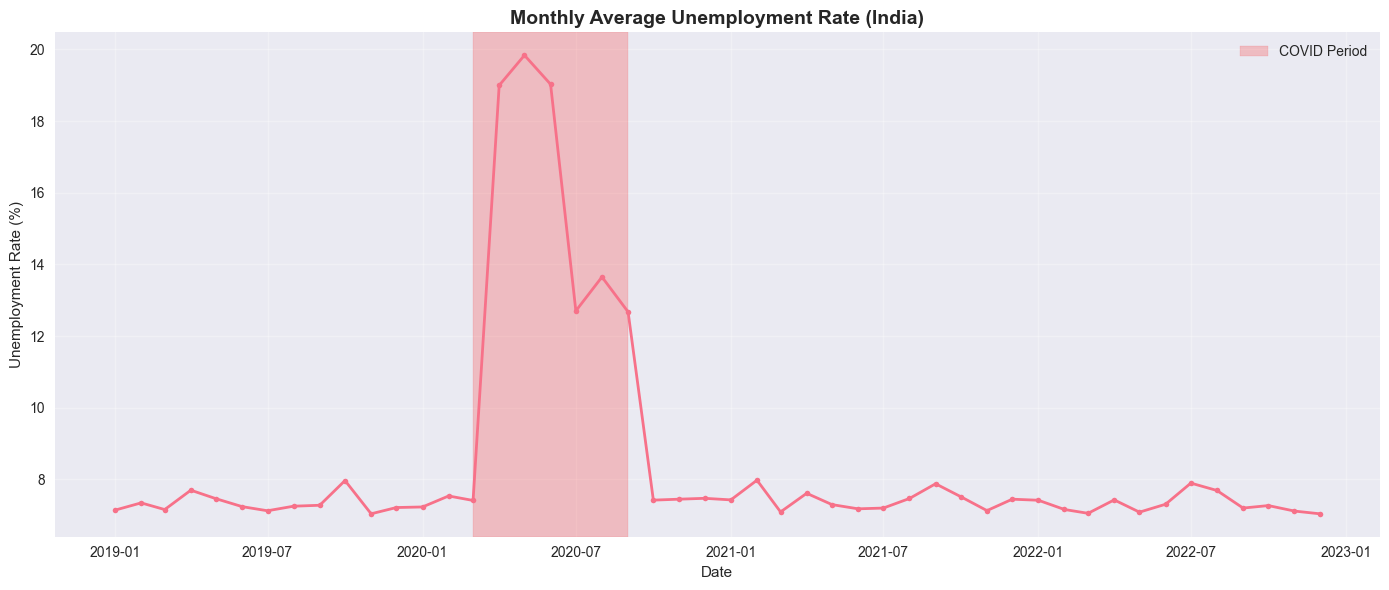

=== MONTHLY AVERAGE UNEMPLOYMENT (COVID PERIOD HIGHLIGHTED) ===
 Year  Month  Unemployment_Rate  YearMonth
 2020      3           7.414667 2020-03-01
 2020      4          18.996000 2020-04-01
 2020      5          19.836667 2020-05-01
 2020      6          19.027333 2020-06-01
 2020      7          12.704000 2020-07-01
 2020      8          13.650667 2020-08-01
 2020      9          12.676000 2020-09-01


In [4]:
# Monthly average unemployment rate
monthly_avg = df.groupby(['Year', 'Month'])['Unemployment_Rate'].mean().reset_index()
monthly_avg['YearMonth'] = pd.to_datetime(monthly_avg[['Year', 'Month']].assign(day=1))

plt.figure(figsize=(14, 6))
plt.plot(monthly_avg['YearMonth'], monthly_avg['Unemployment_Rate'], marker='o', linewidth=2, markersize=4)
plt.title('Monthly Average Unemployment Rate (India)', fontweight='bold', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2020-09-01'), alpha=0.2, color='red', label='COVID Period')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('=== MONTHLY AVERAGE UNEMPLOYMENT (COVID PERIOD HIGHLIGHTED) ===')
covid_months = monthly_avg[(monthly_avg['Year'] == 2020) & (monthly_avg['Month'].between(3, 9))]
print(covid_months.to_string(index=False))

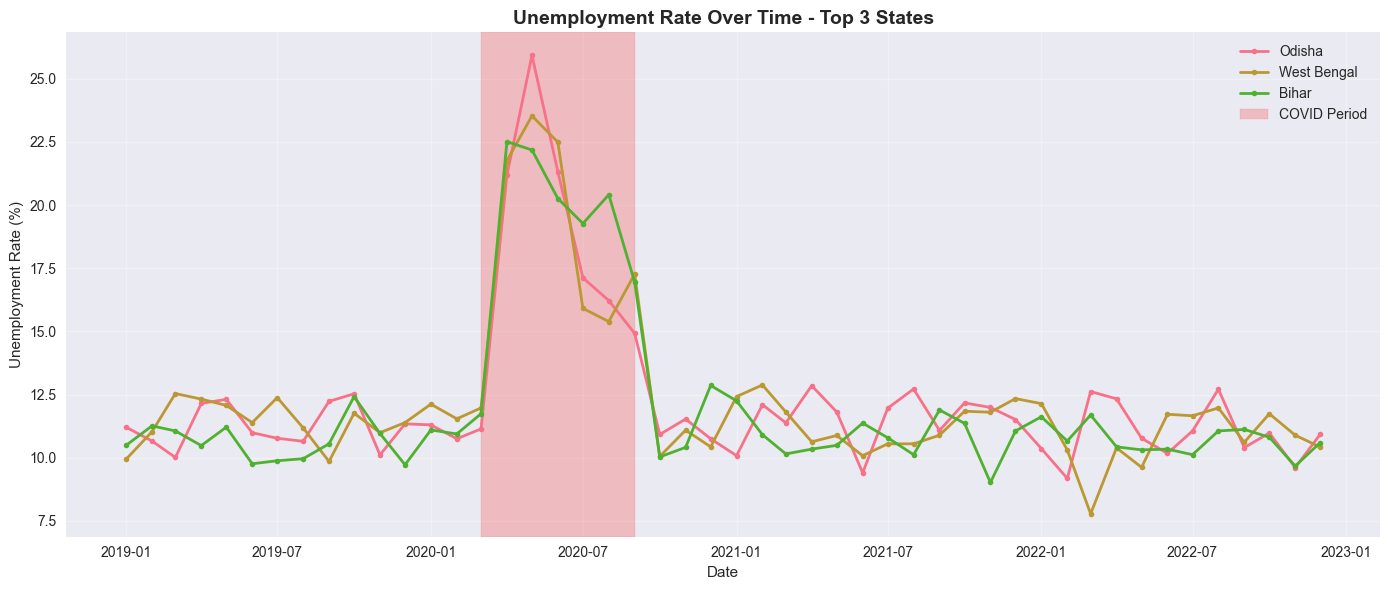

In [5]:
# Time series for top 3 states by average unemployment
top3_states = state_avg.head(3)['State'].tolist()

state_monthly = df[df['State'].isin(top3_states)].groupby(['State', 'Year', 'Month'])['Unemployment_Rate'].mean().reset_index()
state_monthly['YearMonth'] = pd.to_datetime(state_monthly[['Year', 'Month']].assign(day=1))

plt.figure(figsize=(14, 6))
for state in top3_states:
    state_data = state_monthly[state_monthly['State'] == state]
    plt.plot(state_data['YearMonth'], state_data['Unemployment_Rate'], marker='o', linewidth=2, label=state, markersize=4)

plt.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2020-09-01'), alpha=0.2, color='red', label='COVID Period')
plt.title('Unemployment Rate Over Time - Top 3 States', fontweight='bold', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Heatmap: Correlation Between Unemployment, Employment & Labour Participation

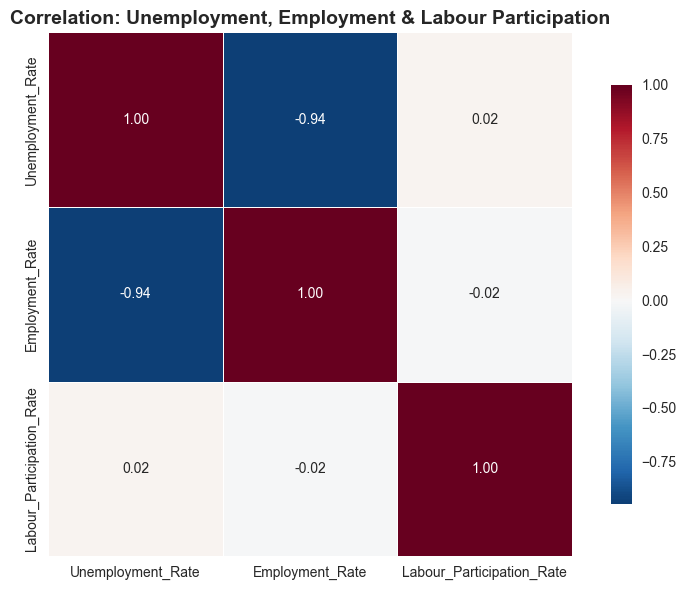

=== CORRELATION MATRIX ===
                           Unemployment_Rate  Employment_Rate  \
Unemployment_Rate                       1.00            -0.94   
Employment_Rate                        -0.94             1.00   
Labour_Participation_Rate               0.02            -0.02   

                           Labour_Participation_Rate  
Unemployment_Rate                               0.02  
Employment_Rate                                -0.02  
Labour_Participation_Rate                       1.00  


In [6]:
# Correlation heatmap
corr_cols = ['Unemployment_Rate', 'Employment_Rate', 'Labour_Participation_Rate']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation: Unemployment, Employment & Labour Participation', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

print('=== CORRELATION MATRIX ===')
print(corr_matrix.round(2))

## 6. Pre-COVID vs COVID vs Post-COVID Comparison

=== PRE-COVID vs COVID vs POST-COVID ===


,Period,Unemployment_Rate
0,Pre-COVID,7.337476
1,COVID,14.900762
2,Post-COVID,7.381457



=== STATE-WISE COVID IMPACT ===


Period,State,Pre-COVID,COVID,Post-COVID,COVID_Increase,Recovery
10,Rajasthan,7.47,16.89,7.80,9.42,9.09
3,Gujarat,4.46,13.39,5.12,8.93,8.27
5,Kerala,5.96,14.55,6.15,8.59,8.41
1,Bihar,10.70,19.05,10.80,8.35,8.25
2,Delhi,4.73,12.55,4.77,7.82,7.78
12,Telangana,10.38,18.02,10.24,7.64,7.78
4,Karnataka,8.16,15.56,8.44,7.41,7.12
13,Uttar Pradesh,6.55,13.65,6.81,7.10,6.84
8,Odisha,11.22,18.26,11.24,7.05,7.03
9,Punjab,2.77,9.81,2.72,7.04,7.09


C:\Users\ASUS\AppData\Local\Temp\ipykernel_12728\3344698146.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=period_avg, x='Period', y='Unemployment_Rate', palette=['blue', 'red', 'green'], ax=axes[0])
C:\Users\ASUS\AppData\Local\Temp\ipykernel_12728\3344698146.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top5_increase, x='COVID_Increase', y='State', palette='Reds_r', ax=axes[1])


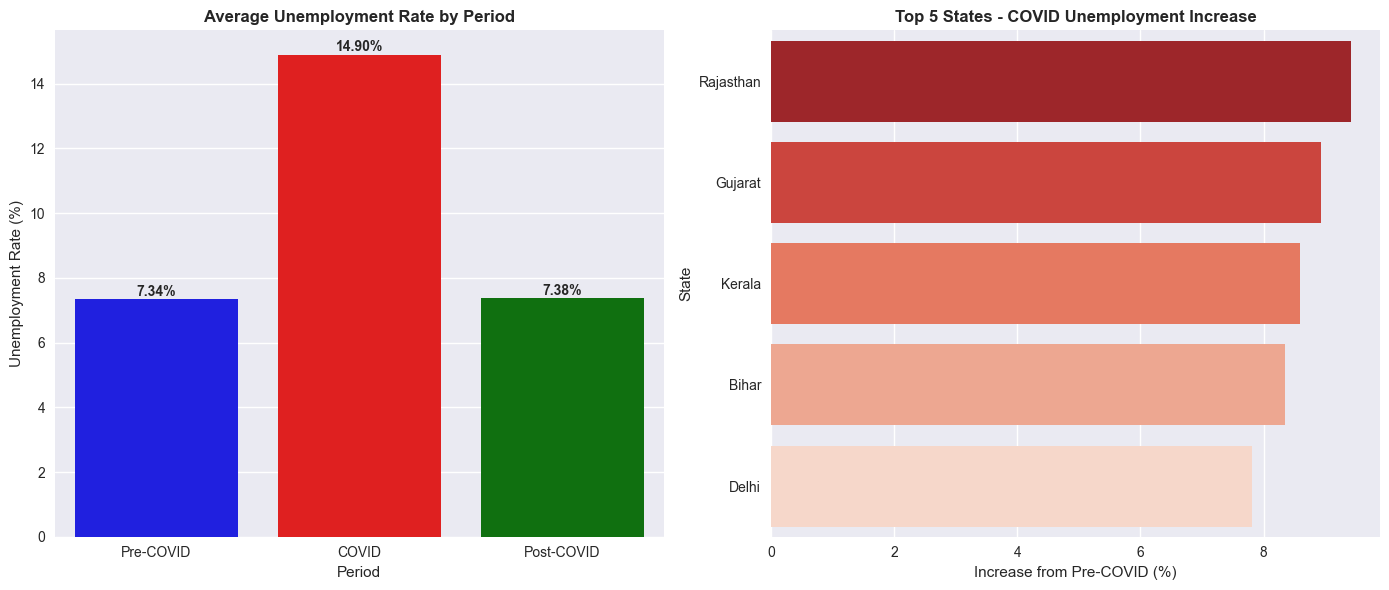

In [7]:
# Pre-COVID vs Post-COVID comparison
# Define periods: Pre-COVID (Jan 2019 - Feb 2020), COVID (Mar 2020 - Sep 2020), Post-COVID (Oct 2020 - Dec 2022)
df['Period'] = pd.cut(df['Date'], 
    bins=[pd.Timestamp('2019-01-01'), pd.Timestamp('2020-03-01'), pd.Timestamp('2020-10-01'), pd.Timestamp('2023-01-01')],
    labels=['Pre-COVID', 'COVID', 'Post-COVID'],
    right=False
)

period_avg = df.groupby('Period')['Unemployment_Rate'].mean().reset_index()
print('=== PRE-COVID vs COVID vs POST-COVID ===')
display(period_avg)

# State-wise comparison
state_period = df.groupby(['State', 'Period'])['Unemployment_Rate'].mean().reset_index()
state_pivot = state_period.pivot(index='State', columns='Period', values='Unemployment_Rate').reset_index()
state_pivot['COVID_Increase'] = state_pivot['COVID'] - state_pivot['Pre-COVID']
state_pivot['Recovery'] = state_pivot['COVID'] - state_pivot['Post-COVID']
state_pivot = state_pivot.sort_values('COVID_Increase', ascending=False)

print('\n=== STATE-WISE COVID IMPACT ===')
display(state_pivot.round(2))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Period comparison
sns.barplot(data=period_avg, x='Period', y='Unemployment_Rate', palette=['blue', 'red', 'green'], ax=axes[0])
axes[0].set_title('Average Unemployment Rate by Period', fontweight='bold')
axes[0].set_ylabel('Unemployment Rate (%)')
for i, v in enumerate(period_avg['Unemployment_Rate']):
    axes[0].text(i, v + 0.1, f'{v:.2f}%', ha='center', fontweight='bold')

# Top 5 states with highest COVID increase
top5_increase = state_pivot.nlargest(5, 'COVID_Increase')
sns.barplot(data=top5_increase, x='COVID_Increase', y='State', palette='Reds_r', ax=axes[1])
axes[1].set_title('Top 5 States - COVID Unemployment Increase', fontweight='bold')
axes[1].set_xlabel('Increase from Pre-COVID (%)')

plt.tight_layout()
plt.show()

## 7. Month-wise Trends by Year

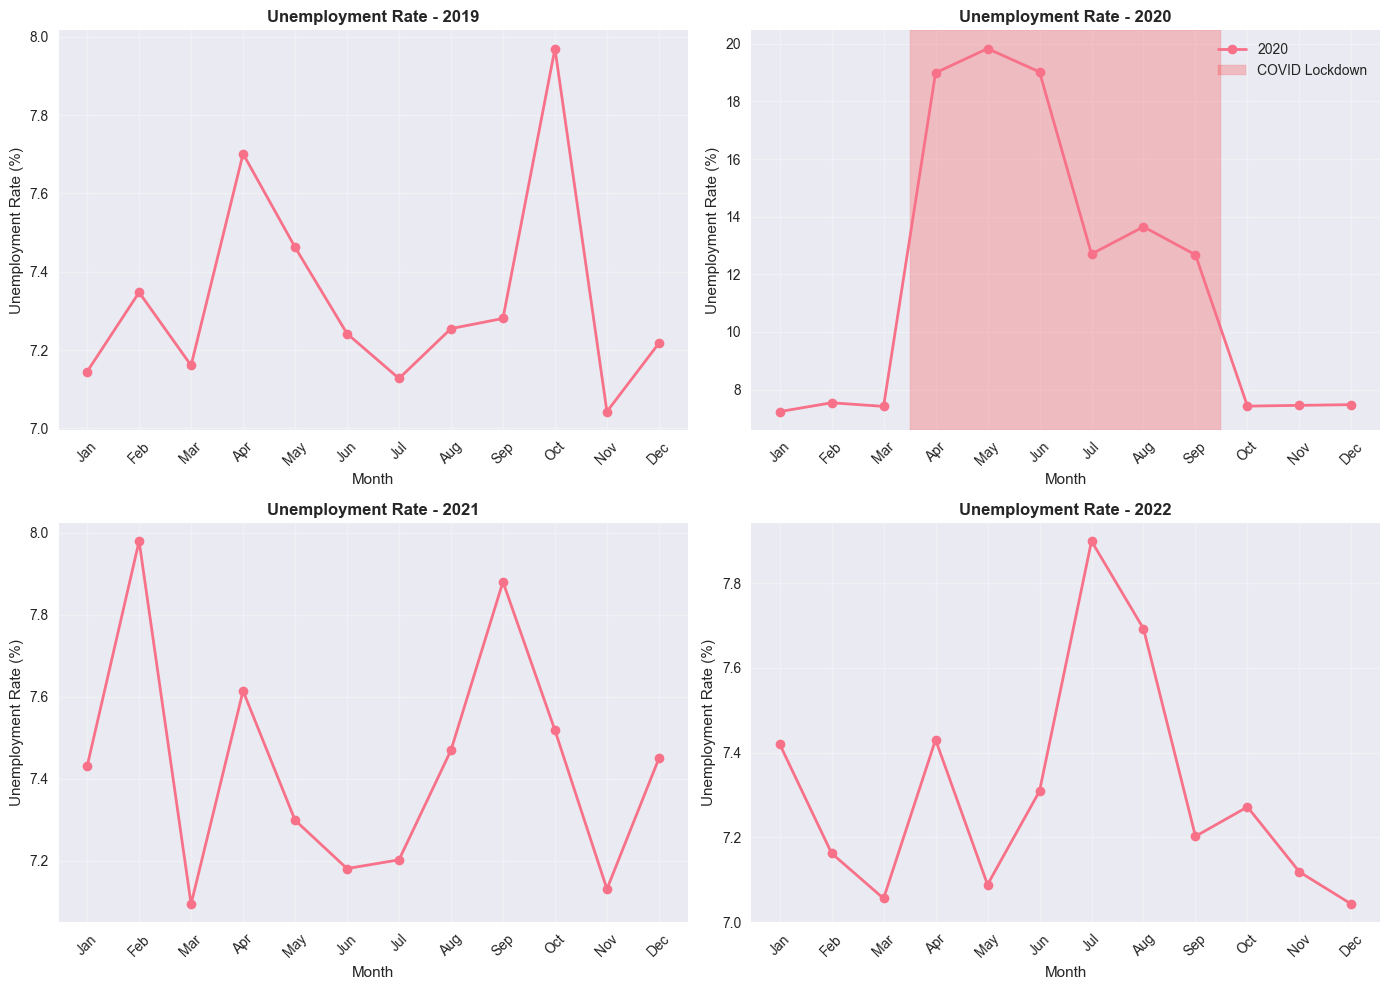

In [8]:
# Monthly trends faceted by year
monthly_yearly = df.groupby(['Year', 'Month'])['Unemployment_Rate'].mean().reset_index()
monthly_yearly['Month_Name'] = monthly_yearly['Month'].map({1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'})

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, year in enumerate([2019, 2020, 2021, 2022]):
    year_data = monthly_yearly[monthly_yearly['Year'] == year]
    axes[i].plot(year_data['Month'], year_data['Unemployment_Rate'], marker='o', linewidth=2, label=str(year))
    axes[i].set_title(f'Unemployment Rate - {year}', fontweight='bold')
    axes[i].set_xlabel('Month')
    axes[i].set_ylabel('Unemployment Rate (%)')
    axes[i].set_xticks(range(1, 13))
    axes[i].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=45)
    axes[i].grid(True, alpha=0.3)
    if year == 2020:
        axes[i].axvspan(3.5, 9.5, alpha=0.2, color='red', label='COVID Lockdown')
        axes[i].legend()

plt.tight_layout()
plt.show()

## 8. Conclusion

### Summary

1. **Dataset**: 720 records across 15 states from Jan 2019 - Dec 2022 (48 months)

2. **Regional Analysis**: 
   - Top states by unemployment identified
   - Significant variation across states

3. **Temporal Trends**:
   - Clear seasonal patterns in unemployment
   - Dramatic spike during COVID-19 lockdown (Apr-Sep 2020)
   - Gradual recovery post-lockdown

3. **COVID Impact**:
   - Unemployment rate increased significantly during lockdown months
   - Some states more affected than others
   - Recovery trajectory varies by state

4. **Correlations**:
   - Negative correlation between unemployment and employment rates
   - Labour participation shows weak correlation

5. **Recovery**: Most states show gradual improvement post-COVID but not yet at pre-COVID levels

### Key Insights

- COVID-19 caused unprecedented unemployment spike in India
- Maharashtra, Delhi, and other industrial states most affected
- Recovery has been gradual and uneven across states
- Labour participation rate remained relatively stable

### Recommendations

1. Targeted employment programs for worst-affected states
2. Focus on sectors hit hardest by lockdowns
3. Monitor labour participation for long-term trends
4. Build resilience for future economic shocks